# Phase 4: Network Analysis

## OB-GYN Provider Network Analysis

---

### Objective

Apply formal network analysis methods to the OB-GYN referral network built in Phase 2 and explored in Phase 3. This notebook quantifies the structural properties of the network — identifying hub providers, isolated regions, tightly-knit communities, and the overall topology of maternal care coordination across the U.S.

### Inputs (from Phase 2)

| File | Description |
|------|-------------|
| `obgyn_providers.csv` | OB-GYN NPIs with practice location and sub-specialty |

**Note:** We use the individual-to-individual edge file (`obgyn_edges_individuals.csv`) which excludes organizational NPIs (hospitals, labs, facilities). This ensures the network analysis reflects provider-level care coordination patterns.
| `obgyn_edges_individuals.csv` | Individual-to-individual shared patient pairs with provider details |
| `county_morbidity_rates.csv` | County-level maternal morbidity rates |

### Analysis Plan

1. Build graphs (full network + OB-GYN-only subgraph)
2. Global topology — components, density, clustering
3. Centrality measures — degree, betweenness, closeness, eigenvector
4. Community detection — Louvain modularity
5. Hub vs. peripheral provider characterization
6. State-level network metrics
7. Export enriched provider table with all network metrics

### Outputs

| File | Description |
|------|-------------|
| `obgyn_providers_network.csv` | Provider table enriched with centrality scores and community labels |
| `community_summary.csv` | Summary statistics per detected community |
| `state_network_metrics.csv` | State-level network topology summary |

---

## 1. Setup

In [1]:
# -------------------------------------------------------------------
# INSTALL: Required packages (run once)
# -------------------------------------------------------------------
# Uncomment and run the line below if networkx/community are not installed:

# !pip install networkx python-louvain scipy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import networkx as nx
import community as community_louvain  # python-louvain package
from scipy import stats
from pathlib import Path
from datetime import datetime
from collections import Counter
import time
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

PROJECT_COLORS = {
    "primary": "#2c7fb8",
    "secondary": "#7fcdbb",
    "accent": "#d95f0e",
    "highlight": "#e34a33"
}

print(f"Notebook executed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"NetworkX version: {nx.__version__}")

Notebook executed: 2026-02-22 19:26:02
NetworkX version: 3.2.1


In [2]:
# -------------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------------

OUTPUT_DIR = Path("../data/outputs")

providers = pd.read_csv(OUTPUT_DIR / "obgyn_providers.csv", dtype=str)
edges = pd.read_csv(OUTPUT_DIR / "obgyn_edges_individuals.csv", dtype={"npi1": str, "npi2": str})
morbidity = pd.read_csv(OUTPUT_DIR / "county_morbidity_rates.csv", dtype={"fips": str})

# Ensure numeric columns
for col in ["benecount", "paircount", "samedaycount"]:
    edges[col] = pd.to_numeric(edges[col], errors="coerce")

OBGYN_NPI_SET = set(providers["npi"])

print(f"Providers: {len(providers):,}")
print(f"Edges:     {len(edges):,}")
print(f"Counties:  {len(morbidity):,}")

Providers: 60,422
Edges:     105,891
Counties:  626


---

## 2. Build Graphs

We construct two graphs:

1. **Full graph** — all individual-to-individual edges (OB-GYN ↔ OB-GYN + OB-GYN ↔ Other). This represents the complete care coordination landscape around OB-GYN providers.
2. **OB-GYN-only subgraph** — only the the OB-GYN ↔ OB-GYN edges. This isolates within-specialty referral patterns, which is better suited for community detection.

Both are **weighted undirected** graphs where the edge weight is `benecount` (number of shared patients).

In [3]:
# -------------------------------------------------------------------
# BUILD: Full weighted graph
# -------------------------------------------------------------------

t0 = time.time()

G_full = nx.Graph()

# Add edges with weight = benecount
for _, row in edges.iterrows():
    G_full.add_edge(
        row["npi1"], row["npi2"],
        weight=row["benecount"],
        paircount=row["paircount"],
        edge_type=row["edge_type"]
    )

# Tag nodes as OB-GYN or other
for node in G_full.nodes():
    G_full.nodes[node]["is_obgyn"] = node in OBGYN_NPI_SET

elapsed = time.time() - t0
print(f"Full graph built in {elapsed:.1f}s")
print(f"  Nodes: {G_full.number_of_nodes():,}")
print(f"  Edges: {G_full.number_of_edges():,}")
print(f"  OB-GYN nodes: {sum(1 for n in G_full.nodes() if G_full.nodes[n]['is_obgyn']):,}")
print(f"  Non-OB-GYN nodes: {sum(1 for n in G_full.nodes() if not G_full.nodes[n]['is_obgyn']):,}")

Full graph built in 5.3s
  Nodes: 49,341
  Edges: 70,980
  OB-GYN nodes: 12,227
  Non-OB-GYN nodes: 37,114


In [4]:
# -------------------------------------------------------------------
# BUILD: OB-GYN-only subgraph
# -------------------------------------------------------------------

obgyn_edges_only = edges[edges["edge_type"] == "obgyn_obgyn"]

G_obgyn = nx.Graph()
for _, row in obgyn_edges_only.iterrows():
    G_obgyn.add_edge(
        row["npi1"], row["npi2"],
        weight=row["benecount"],
        paircount=row["paircount"]
    )

print(f"OB-GYN-only subgraph:")
print(f"  Nodes: {G_obgyn.number_of_nodes():,}")
print(f"  Edges: {G_obgyn.number_of_edges():,}")
print(f"  Density: {nx.density(G_obgyn):.6f}")

OB-GYN-only subgraph:
  Nodes: 2,791
  Edges: 2,429
  Density: 0.000624


---

## 3. Global Topology

Basic structural properties of both graphs — connected components, density, and clustering.

In [5]:
# -------------------------------------------------------------------
# 3a. Connected Components — Full Graph
# -------------------------------------------------------------------

components_full = sorted(nx.connected_components(G_full), key=len, reverse=True)
component_sizes_full = [len(c) for c in components_full]

print(f"Full Graph — Connected Components:")
print(f"  Total components: {len(components_full):,}")
print(f"  Giant component:  {component_sizes_full[0]:,} nodes "
      f"({component_sizes_full[0]/G_full.number_of_nodes()*100:.1f}% of graph)")
if len(component_sizes_full) > 1:
    print(f"  2nd largest:      {component_sizes_full[1]:,} nodes")
print(f"  Isolated nodes:   {sum(1 for s in component_sizes_full if s == 1):,}")

# Component size distribution
print(f"\n  Component size distribution:")
size_bins = pd.cut(component_sizes_full,
                   bins=[0, 1, 5, 20, 100, 1000, max(component_sizes_full)+1],
                   labels=["1 (isolated)", "2-5", "6-20", "21-100", "101-1000", "1000+"])
for label, count in size_bins.value_counts().sort_index().items():
    print(f"    {label}: {count:,} components")

Full Graph — Connected Components:
  Total components: 1,895
  Giant component:  25,327 nodes (51.3% of graph)
  2nd largest:      653 nodes
  Isolated nodes:   0

  Component size distribution:
    1 (isolated): 0 components
    2-5: 1,205 components
    6-20: 445 components
    21-100: 212 components
    101-1000: 32 components
    1000+: 1 components


In [6]:
# -------------------------------------------------------------------
# 3b. Connected Components — OB-GYN Subgraph
# -------------------------------------------------------------------

components_obgyn = sorted(nx.connected_components(G_obgyn), key=len, reverse=True)
component_sizes_obgyn = [len(c) for c in components_obgyn]

print(f"OB-GYN Subgraph — Connected Components:")
print(f"  Total components: {len(components_obgyn):,}")
print(f"  Giant component:  {component_sizes_obgyn[0]:,} nodes "
      f"({component_sizes_obgyn[0]/G_obgyn.number_of_nodes()*100:.1f}% of subgraph)")
if len(component_sizes_obgyn) > 1:
    print(f"  2nd largest:      {component_sizes_obgyn[1]:,} nodes")
print(f"  Isolated pairs:   {sum(1 for s in component_sizes_obgyn if s == 2):,}")

OB-GYN Subgraph — Connected Components:
  Total components: 957
  Giant component:  28 nodes (1.0% of subgraph)
  2nd largest:      22 nodes
  Isolated pairs:   601


In [7]:
# -------------------------------------------------------------------
# 3c. Graph Density & Clustering
# -------------------------------------------------------------------

print(f"Graph-level metrics:")
print(f"{'Metric':<40} {'Full Graph':>15} {'OB-GYN Only':>15}")
print("-" * 72)
print(f"{'Nodes':<40} {G_full.number_of_nodes():>15,} {G_obgyn.number_of_nodes():>15,}")
print(f"{'Edges':<40} {G_full.number_of_edges():>15,} {G_obgyn.number_of_edges():>15,}")
print(f"{'Density':<40} {nx.density(G_full):>15.6f} {nx.density(G_obgyn):>15.6f}")
print(f"{'Components':<40} {len(components_full):>15,} {len(components_obgyn):>15,}")
print(f"{'Giant component (% of nodes)':<40} {component_sizes_full[0]/G_full.number_of_nodes()*100:>14.1f}% {component_sizes_obgyn[0]/G_obgyn.number_of_nodes()*100:>14.1f}%")

# Average clustering (this can take a moment on the full graph)
print(f"\nComputing average clustering coefficient...")
t0 = time.time()
avg_clustering_full = nx.average_clustering(G_full, weight="weight")
avg_clustering_obgyn = nx.average_clustering(G_obgyn, weight="weight")
print(f"  Full graph:  {avg_clustering_full:.4f}  ({time.time()-t0:.1f}s)")
print(f"  OB-GYN only: {avg_clustering_obgyn:.4f}")

Graph-level metrics:
Metric                                        Full Graph     OB-GYN Only
------------------------------------------------------------------------
Nodes                                             49,341           2,791
Edges                                             70,980           2,429
Density                                         0.000058        0.000624
Components                                         1,895             957
Giant component (% of nodes)                       51.3%            1.0%

Computing average clustering coefficient...
  Full graph:  0.0020  (1.0s)
  OB-GYN only: 0.0268


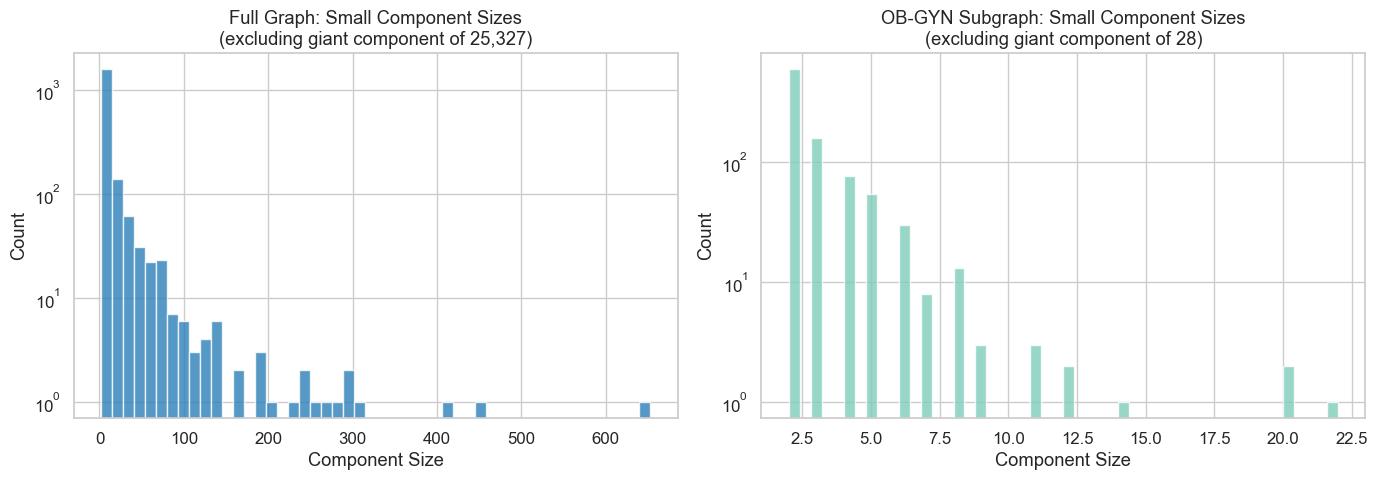

In [8]:
# -------------------------------------------------------------------
# 3d. Component Size Distribution Plot
# -------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full graph component sizes (excluding giant component for readability)
small_components = [s for s in component_sizes_full if s < component_sizes_full[0]]
if small_components:
    axes[0].hist(small_components, bins=50, color=PROJECT_COLORS["primary"],
                 edgecolor="white", alpha=0.8)
    axes[0].set_xlabel("Component Size")
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"Full Graph: Small Component Sizes\n(excluding giant component of {component_sizes_full[0]:,})")
    axes[0].set_yscale("log")

# OB-GYN subgraph
small_obgyn = [s for s in component_sizes_obgyn if s < component_sizes_obgyn[0]]
if small_obgyn:
    axes[1].hist(small_obgyn, bins=50, color=PROJECT_COLORS["secondary"],
                 edgecolor="white", alpha=0.8)
    axes[1].set_xlabel("Component Size")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"OB-GYN Subgraph: Small Component Sizes\n(excluding giant component of {component_sizes_obgyn[0]:,})")
    axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

---

## 4. Centrality Measures

We compute four centrality measures to identify important providers from different perspectives:

| Measure | What It Captures | Analogy |
|---------|------------------|---------|
| **Degree centrality** | Number of connections | How many other doctors does this OB-GYN share patients with? |
| **Weighted degree** | Total shared patients | Volume of care coordination |
| **Betweenness centrality** | Bridge position between groups | Does this OB-GYN connect otherwise separate clusters of providers? |
| **Eigenvector centrality** | Connected to other well-connected providers | Is this OB-GYN connected to other 'important' providers? |

**Note:** Betweenness centrality is computed on a **sampled approximation** (`k=1000` random source nodes) for performance — exact computation on a 70K+ node graph would take hours.

In [9]:
# -------------------------------------------------------------------
# 4a. Degree Centrality (Full Graph)
# -------------------------------------------------------------------

t0 = time.time()
degree_centrality = nx.degree_centrality(G_full)
print(f"Degree centrality computed in {time.time()-t0:.1f}s")

# Weighted degree (strength): sum of edge weights per node
weighted_degree = dict(G_full.degree(weight="weight"))

print(f"\nDegree centrality (OB-GYN nodes only):")
obgyn_dc = {n: degree_centrality[n] for n in G_full.nodes() if G_full.nodes[n]["is_obgyn"]}
dc_values = list(obgyn_dc.values())
print(f"  Mean:   {np.mean(dc_values):.6f}")
print(f"  Median: {np.median(dc_values):.6f}")
print(f"  Max:    {max(dc_values):.6f}")

Degree centrality computed in 0.1s

Degree centrality (OB-GYN nodes only):
  Mean:   0.000122
  Median: 0.000041
  Max:    0.009080


In [10]:
# -------------------------------------------------------------------
# 4b. Betweenness Centrality (Approximate — Full Graph)
# -------------------------------------------------------------------
# Using k=1000 sampled source nodes for approximation.
# On a 70K-node graph, exact computation would take hours.
# -------------------------------------------------------------------

t0 = time.time()
print("Computing approximate betweenness centrality (k=1000)...")
betweenness = nx.betweenness_centrality(G_full, k=1000, weight="weight", seed=42)
elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s")

obgyn_bc = {n: betweenness[n] for n in G_full.nodes() if G_full.nodes[n]["is_obgyn"]}
bc_values = list(obgyn_bc.values())
print(f"\nBetweenness centrality (OB-GYN nodes):")
print(f"  Mean:   {np.mean(bc_values):.6f}")
print(f"  Median: {np.median(bc_values):.6f}")
print(f"  Max:    {max(bc_values):.6f}")

Computing approximate betweenness centrality (k=1000)...
Done in 133.8s

Betweenness centrality (OB-GYN nodes):
  Mean:   0.000236
  Median: 0.000000
  Max:    0.051921


In [11]:
# -------------------------------------------------------------------
# 4c. Eigenvector Centrality (Full Graph)
# -------------------------------------------------------------------

t0 = time.time()
print("Computing eigenvector centrality (numpy solver)...")

try:
    eigenvector = nx.eigenvector_centrality_numpy(G_full, weight="weight")
    print(f"Done in {time.time()-t0:.1f}s")
except Exception as e:
    print(f"Full graph failed: {e}")
    print("Computing on giant component only...")
    giant_nodes = components_full[0]
    G_giant = G_full.subgraph(giant_nodes)
    eigenvector_giant = nx.eigenvector_centrality_numpy(G_giant, weight="weight")
    eigenvector = {n: eigenvector_giant.get(n, 0.0) for n in G_full.nodes()}
    print(f"Done in {time.time()-t0:.1f}s (giant component only)")

obgyn_ec = {n: eigenvector[n] for n in G_full.nodes() if G_full.nodes[n]["is_obgyn"]}
ec_values = list(obgyn_ec.values())
print(f"\nEigenvector centrality (OB-GYN nodes):")
print(f"  Mean:   {np.mean(ec_values):.6f}")
print(f"  Median: {np.median(ec_values):.6f}")
print(f"  Max:    {max(ec_values):.6f}")

Computing eigenvector centrality (numpy solver)...
Done in 0.4s

Eigenvector centrality (OB-GYN nodes):
  Mean:   0.000061
  Median: 0.000000
  Max:    0.706788


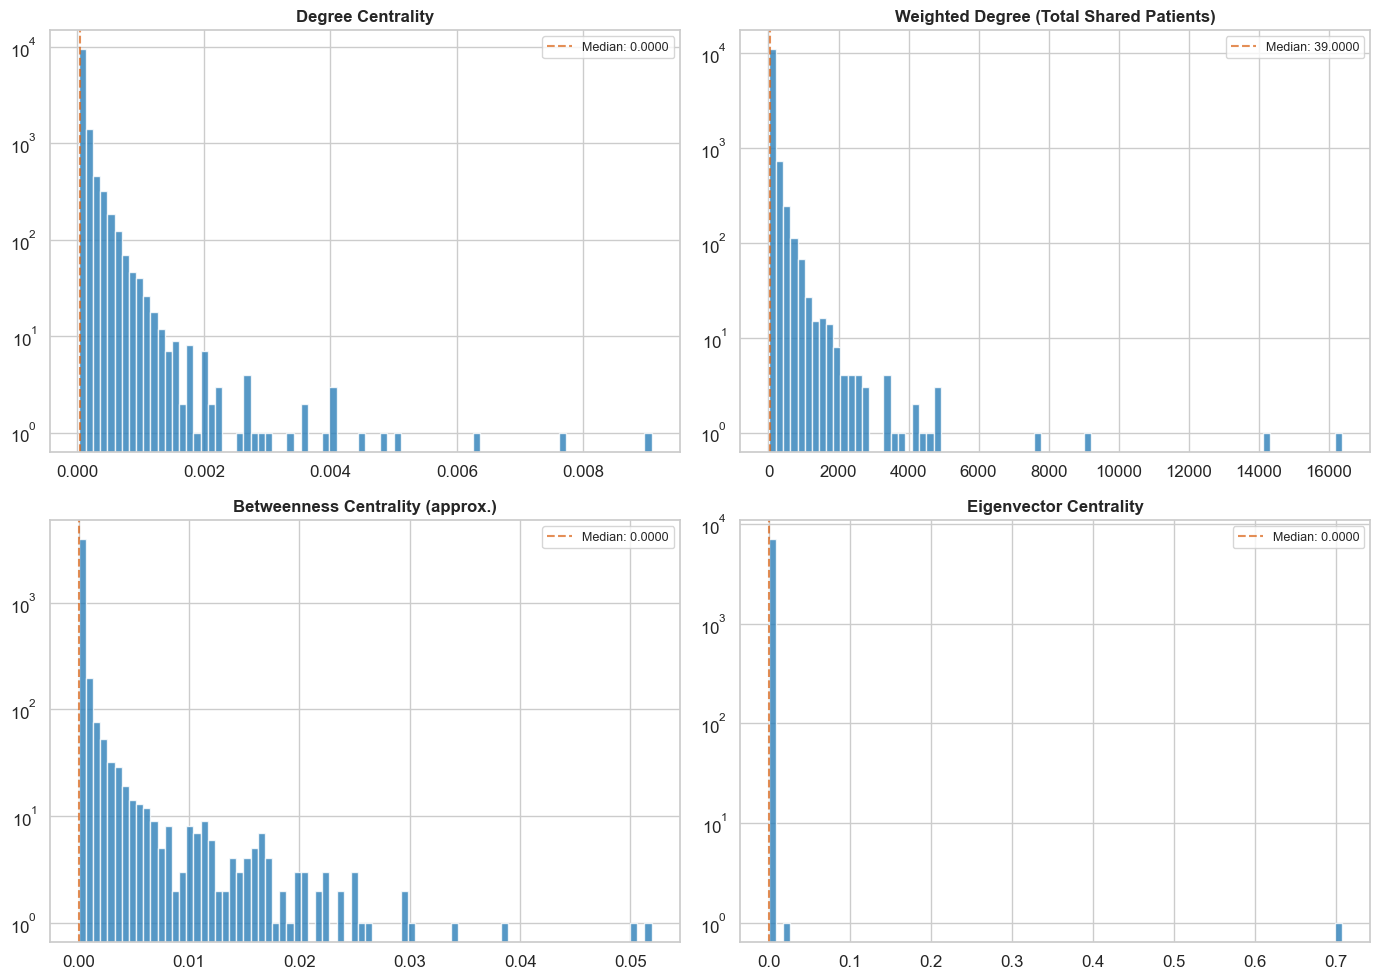

In [12]:
# -------------------------------------------------------------------
# 4d. Centrality Distribution Plots
# -------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = [
    (obgyn_dc, "Degree Centrality", axes[0, 0]),
    ({n: weighted_degree.get(n, 0) for n in OBGYN_NPI_SET if n in weighted_degree},
     "Weighted Degree (Total Shared Patients)", axes[0, 1]),
    (obgyn_bc, "Betweenness Centrality (approx.)", axes[1, 0]),
    (obgyn_ec, "Eigenvector Centrality", axes[1, 1]),
]

for data, title, ax in metrics:
    values = [v for v in data.values() if v > 0]
    if values:
        ax.hist(values, bins=80, color=PROJECT_COLORS["primary"],
                edgecolor="white", alpha=0.8)
        ax.set_yscale("log")
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.axvline(np.median(values), color=PROJECT_COLORS["accent"],
                   linestyle="--", alpha=0.7, label=f"Median: {np.median(values):.4f}")
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
# -------------------------------------------------------------------
# EXPORT: Betweenness centrality distribution for Tableau bar chart
# -------------------------------------------------------------------
# Pre-binned into human-readable tiers.
# Tableau: Betweenness Range on Rows, Provider Count on Columns.
# -------------------------------------------------------------------

provider_net_reload = pd.read_csv(OUTPUT_DIR / "obgyn_providers_network.csv", dtype={"npi": str})
provider_net_reload["betweenness"] = pd.to_numeric(provider_net_reload["betweenness"], errors="coerce")

def betweenness_bin(val):
    if val == 0:
        return "1. Zero (no bridge role)"
    elif val < 0.0001:
        return "2. Minimal (< 0.0001)"
    elif val < 0.001:
        return "3. Low (0.0001 – 0.001)"
    elif val < 0.005:
        return "4. Moderate (0.001 – 0.005)"
    else:
        return "5. High (≥ 0.005)"

provider_net_reload["Betweenness Range"] = provider_net_reload["betweenness"].apply(betweenness_bin)

bc_export = (
    provider_net_reload
    .groupby("Betweenness Range")
    .agg(Provider_Count=("npi", "count"))
    .reset_index()
)

bc_export["Percent of Total"] = (bc_export["Provider_Count"] / len(provider_net_reload) * 100).round(1)
bc_export.columns = ["Betweenness Range", "Provider Count", "Percent of Total"]

bc_export.to_csv(OUTPUT_DIR / "tableau_betweenness_distribution.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'tableau_betweenness_distribution.csv'}")
display(bc_export)

Saved: ../data/outputs/tableau_betweenness_distribution.csv


,Betweenness Range,Provider Count,Percent of Total
0,1. Zero (no bridge role),47470,78.6
1,2. Minimal (< 0.0001),9750,16.1
2,3. Low (0.0001 – 0.001),2354,3.9
3,4. Moderate (0.001 – 0.005),768,1.3
4,5. High (≥ 0.005),80,0.1


---

## 5. Community Detection (Louvain)

We apply the **Louvain method** to detect communities — groups of providers who share patients more densely with each other than with the rest of the network. We run this on the **OB-GYN-only subgraph** to find within-specialty referral communities, which are more interpretable than communities in the mixed graph.

Communities often correspond to geographic regions (same city/hospital system) or practice affiliations.

In [14]:
# -------------------------------------------------------------------
# 5a. Run Louvain on OB-GYN Subgraph
# -------------------------------------------------------------------

t0 = time.time()
partition = community_louvain.best_partition(G_obgyn, weight="weight", random_state=42)
modularity = community_louvain.modularity(partition, G_obgyn, weight="weight")

n_communities = len(set(partition.values()))
print(f"Louvain community detection completed in {time.time()-t0:.1f}s")
print(f"  Communities found: {n_communities}")
print(f"  Modularity score:  {modularity:.4f}")
print(f"  (Modularity > 0.3 indicates strong community structure)")

Louvain community detection completed in 0.1s
  Communities found: 957
  Modularity score:  0.9954
  (Modularity > 0.3 indicates strong community structure)


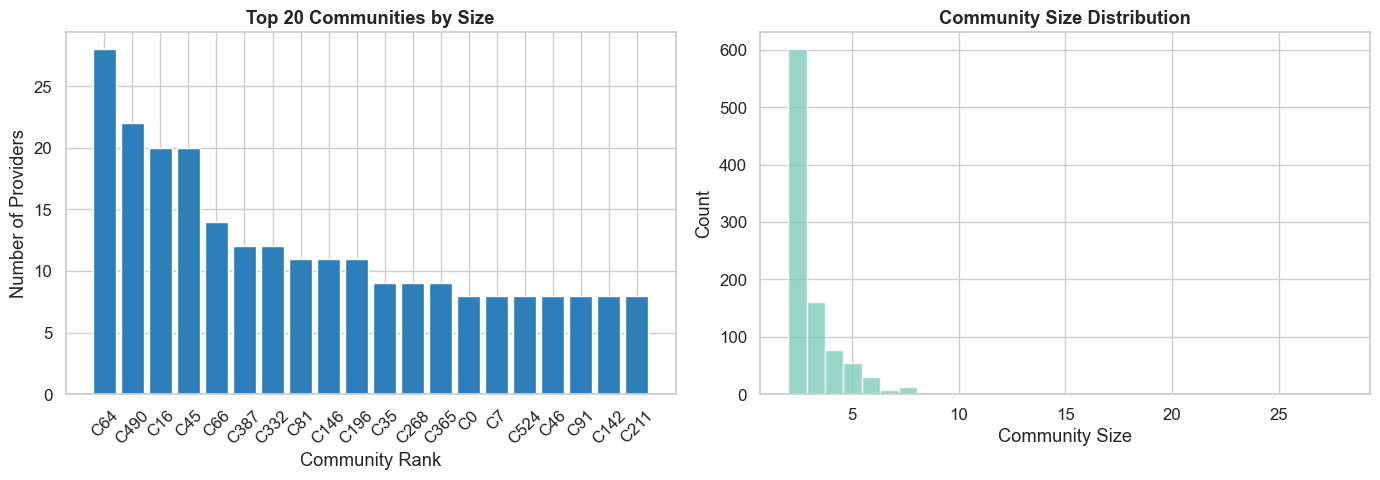

Community size summary:
  Median size: 2
  Mean size:   2.9
  Largest:     28
  Smallest:    2
  Communities with 1 provider:  0
  Communities with 10+ providers: 10


In [15]:
# -------------------------------------------------------------------
# 5b. Community Size Distribution
# -------------------------------------------------------------------

community_sizes = Counter(partition.values())
comm_sizes_sorted = sorted(community_sizes.values(), reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Bar chart of top 20 communities
top20_comm = sorted(community_sizes.items(), key=lambda x: x[1], reverse=True)[:20]
comm_ids, comm_counts = zip(*top20_comm)
axes[0].bar(range(len(comm_ids)), comm_counts, color=PROJECT_COLORS["primary"],
            edgecolor="white")
axes[0].set_xlabel("Community Rank")
axes[0].set_ylabel("Number of Providers")
axes[0].set_title("Top 20 Communities by Size", fontweight="bold")
axes[0].set_xticks(range(len(comm_ids)))
axes[0].set_xticklabels([f"C{cid}" for cid in comm_ids], rotation=45)

# Right: Full distribution
axes[1].hist(comm_sizes_sorted, bins=30, color=PROJECT_COLORS["secondary"],
             edgecolor="white", alpha=0.8)
axes[1].set_xlabel("Community Size")
axes[1].set_ylabel("Count")
axes[1].set_title("Community Size Distribution", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Community size summary:")
print(f"  Median size: {np.median(comm_sizes_sorted):.0f}")
print(f"  Mean size:   {np.mean(comm_sizes_sorted):.1f}")
print(f"  Largest:     {comm_sizes_sorted[0]}")
print(f"  Smallest:    {comm_sizes_sorted[-1]}")
print(f"  Communities with 1 provider:  {sum(1 for s in comm_sizes_sorted if s == 1)}")
print(f"  Communities with 10+ providers: {sum(1 for s in comm_sizes_sorted if s >= 10)}")

In [16]:
# -------------------------------------------------------------------
# 5c. Characterize Top Communities by Geography
# -------------------------------------------------------------------

# Build a community-to-provider mapping with state/city info
comm_df = pd.DataFrame([
    {"npi": npi, "community": comm_id}
    for npi, comm_id in partition.items()
])

comm_df = comm_df.merge(providers[["npi", "subspecialty", "city", "state"]], on="npi", how="left")

# For each of the top 15 communities, show dominant state and city
top15_comms = [cid for cid, _ in sorted(community_sizes.items(), key=lambda x: x[1], reverse=True)[:15]]

comm_profiles = []
for cid in top15_comms:
    subset = comm_df[comm_df["community"] == cid]
    top_state = subset["state"].mode().iloc[0] if len(subset["state"].dropna()) > 0 else "N/A"
    top_city = subset["city"].mode().iloc[0] if len(subset["city"].dropna()) > 0 else "N/A"
    state_pct = (subset["state"] == top_state).sum() / len(subset) * 100
    comm_profiles.append({
        "community": cid,
        "size": len(subset),
        "top_state": top_state,
        "state_pct": round(state_pct, 1),
        "top_city": top_city,
        "n_states": subset["state"].nunique(),
        "top_subspecialty": subset["subspecialty"].mode().iloc[0] if len(subset) > 0 else "N/A"
    })

comm_profile_df = pd.DataFrame(comm_profiles)
print("Top 15 Communities — Geographic Profile:")
display(comm_profile_df)

Top 15 Communities — Geographic Profile:


,community,size,top_state,state_pct,top_city,n_states,top_subspecialty
0,64,28,MO,64.3,SAINT LOUIS,11,Obstetrics & Gynecology
1,490,22,NY,77.3,ROCHESTER,6,Obstetrics & Gynecology
2,16,20,IL,40.0,CHICAGO,7,Gynecologic Oncology
3,45,20,RI,55.0,PROVIDENCE,4,Obstetrics & Gynecology
4,66,14,WV,100.0,BECKLEY,1,Obstetrics & Gynecology
5,387,12,CA,100.0,SAN FRANCISCO,1,Obstetrics & Gynecology
6,332,12,NC,91.7,ASHEVILLE,2,Obstetrics & Gynecology
7,81,11,MA,90.9,SPRINGFIELD,2,Obstetrics & Gynecology
8,146,11,NC,90.9,GREENVILLE,2,Obstetrics & Gynecology
9,196,11,PA,54.5,DANVILLE,6,Obstetrics & Gynecology


In [17]:
# -------------------------------------------------------------------
# EXPORT: Community geographic profiles for Tableau table
# -------------------------------------------------------------------
# All communities with 5+ providers for meaningful clusters.
# -------------------------------------------------------------------

all_comms = sorted(community_sizes.items(), key=lambda x: x[1], reverse=True)
comms_5plus = [(cid, size) for cid, size in all_comms if size >= 5]

comm_profiles_all = []
for cid, _ in comms_5plus:
    subset = comm_df[comm_df["community"] == cid]
    top_state = subset["state"].mode().iloc[0] if len(subset["state"].dropna()) > 0 else "N/A"
    top_city = subset["city"].mode().iloc[0] if len(subset["city"].dropna()) > 0 else "N/A"
    state_pct = (subset["state"] == top_state).sum() / len(subset) * 100
    comm_profiles_all.append({
        "Community": cid,
        "OB-GYN Count": len(subset),
        "Primary State": top_state,
        "State Concentration (%)": round(state_pct, 1),
        "Primary City": top_city,
        "States Spanned": subset["state"].nunique(),
        "Top Subspecialty": subset["subspecialty"].mode().iloc[0] if len(subset) > 0 else "N/A"
    })

comm_export = pd.DataFrame(comm_profiles_all)
comm_export.to_csv(OUTPUT_DIR / "tableau_community_profiles.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'tableau_community_profiles.csv'}")
print(f"  {len(comm_export)} communities with 5+ OB-GYNs")
display(comm_export)

Saved: ../data/outputs/tableau_community_profiles.csv
  118 communities with 5+ OB-GYNs


,Community,OB-GYN Count,Primary State,State Concentration (%),Primary City,States Spanned,Top Subspecialty
0,64,28,MO,64.3,SAINT LOUIS,11,Obstetrics & Gynecology
1,490,22,NY,77.3,ROCHESTER,6,Obstetrics & Gynecology
2,16,20,IL,40.0,CHICAGO,7,Gynecologic Oncology
3,45,20,RI,55.0,PROVIDENCE,4,Obstetrics & Gynecology
4,66,14,WV,100.0,BECKLEY,1,Obstetrics & Gynecology
...,...,...,...,...,...,...,...
113,691,5,NY,100.0,MOUNT KISCO,1,Obstetrics & Gynecology
114,705,5,NY,100.0,BROOKLYN,1,Gynecologic Oncology
115,711,5,NJ,60.0,DUARTE,3,Gynecologic Oncology
116,763,5,PA,100.0,PHILADELPHIA,1,Obstetrics & Gynecology


---

## 6. Hub vs. Peripheral Provider Analysis

Classifying OB-GYN providers into tiers based on their network position. Hub providers are the backbone of care coordination; peripheral providers may represent areas where virtual care models could bridge gaps.

In [18]:
# -------------------------------------------------------------------
# 6a. Build Enriched Provider Table with All Network Metrics
# -------------------------------------------------------------------

provider_net = providers.copy()

# Degree centrality
provider_net["degree_centrality"] = provider_net["npi"].map(degree_centrality).fillna(0)

# Weighted degree (strength)
provider_net["weighted_degree"] = provider_net["npi"].map(weighted_degree).fillna(0).astype(int)

# Betweenness centrality
provider_net["betweenness"] = provider_net["npi"].map(betweenness).fillna(0)

# Eigenvector centrality
provider_net["eigenvector"] = provider_net["npi"].map(eigenvector).fillna(0)

# Community assignment (from OB-GYN subgraph)
provider_net["community"] = provider_net["npi"].map(partition).fillna(-1).astype(int)

# Total degree (simple count of connections)
degree_dict = dict(G_full.degree())
provider_net["total_degree"] = provider_net["npi"].map(degree_dict).fillna(0).astype(int)

# OB-GYN degree (connections to other OB-GYNs only)
obgyn_degree_dict = dict(G_obgyn.degree())
provider_net["obgyn_degree"] = provider_net["npi"].map(obgyn_degree_dict).fillna(0).astype(int)

# Connected to network?
provider_net["is_connected"] = provider_net["total_degree"] > 0

print(f"Provider network table: {len(provider_net):,} rows x {len(provider_net.columns)} cols")
print(f"\nNew columns added: degree_centrality, weighted_degree, betweenness, ")
print(f"  eigenvector, community, total_degree, obgyn_degree, is_connected")
display(provider_net.head(5))

Provider network table: 60,422 rows x 17 cols

New columns added: degree_centrality, weighted_degree, betweenness, 
  eigenvector, community, total_degree, obgyn_degree, is_connected


,npi,last_name,first_name,taxonomy_code,subspecialty,city,state,zip_raw,zip5,degree_centrality,weighted_degree,betweenness,eigenvector,community,total_degree,obgyn_degree,is_connected
0,1487657532,HUEBERT,ALLISON,207V00000X,Obstetrics & Gynecology,TULSA,OK,741352527,74135,0.000041,22,4.053671e-08,8.427093e-20,-1,2,0,True
1,1396748349,GRUNERT,GEORGE,207VE0102X,Reproductive Endocrinology,HOUSTON,TX,770632313,77063,0.000000,0,0.000000e+00,0.000000e+00,-1,0,0,False
2,1861495814,SMITH,FRANCISCO,207VX0201X,Gynecologic Oncology,NAPLES,FL,341101497,34110,0.000000,0,0.000000e+00,0.000000e+00,-1,0,0,False
3,1003819046,NYLANDER,BARBARA,207VG0400X,Gynecology,NASHVILLE,TN,372031513,37203,0.000041,24,1.054968e-04,1.227660e-07,-1,2,0,True
4,1932102969,HELFER,TAMARA,207V00000X,Obstetrics & Gynecology,CARMEL,IN,460323008,46032,0.000020,14,0.000000e+00,-4.069511e-19,-1,1,0,True


In [19]:
# -------------------------------------------------------------------
# 6b. Provider Tier Classification
# -------------------------------------------------------------------
# Classify providers into tiers based on their total degree:
#   Hub:        Top 10% by degree (well-connected coordinators)
#   Connected:  Middle 60% (moderate connections)
#   Peripheral: Bottom 30% of connected (few connections)
#   Isolated:   Zero connections in the network
# -------------------------------------------------------------------

connected_providers = provider_net[provider_net["is_connected"]]

p70 = connected_providers["total_degree"].quantile(0.70)
p90 = connected_providers["total_degree"].quantile(0.90)

def classify_tier(row):
    if row["total_degree"] == 0:
        return "Isolated"
    elif row["total_degree"] >= p90:
        return "Hub"
    elif row["total_degree"] >= p70:
        return "Connected"
    else:
        return "Peripheral"

provider_net["tier"] = provider_net.apply(classify_tier, axis=1)

tier_summary = provider_net.groupby("tier").agg(
    count=("npi", "count"),
    mean_degree=("total_degree", "mean"),
    mean_weighted_degree=("weighted_degree", "mean"),
    mean_betweenness=("betweenness", "mean"),
    mean_eigenvector=("eigenvector", "mean")
).round(4)

tier_summary["pct"] = (tier_summary["count"] / len(provider_net) * 100).round(1)

# Reorder
tier_order = ["Hub", "Connected", "Peripheral", "Isolated"]
tier_summary = tier_summary.reindex(tier_order)

print("Provider Tier Summary:")
display(tier_summary)

Provider Tier Summary:


,count,mean_degree,mean_weighted_degree,mean_betweenness,mean_eigenvector,pct
tier,,,,,,
Hub,1225,30.4816,587.4522,0.0011,0.0006,2.0
Connected,2701,7.5761,121.8756,0.0003,0.0000,4.5
Peripheral,8301,1.8800,29.4814,0.0001,0.0000,13.7
Isolated,48195,0.0000,0.0000,0.0000,0.0000,79.8


In [24]:
# -------------------------------------------------------------------
# EXPORT: Provider tier distribution for Tableau pie chart
# -------------------------------------------------------------------

tier_order = ["Hub", "Connected", "Peripheral", "Isolated"]

tier_export = provider_net["tier"].value_counts().reindex(tier_order).reset_index()
tier_export.columns = ["Provider Tier", "Provider Count"]
tier_export["Percent"] = (tier_export["Provider Count"] / len(provider_net) * 100).round(1)
tier_export["Label"] = (
    tier_export["Provider Tier"] + " — " +
    tier_export["Provider Count"].apply(lambda x: f"{x:,}") + " (" +
    tier_export["Percent"].astype(str) + "%)"
)

tier_export.to_csv(OUTPUT_DIR / "tableau_provider_tiers_pie.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'tableau_provider_tiers_pie.csv'}")
display(tier_export)

Saved: ../data/outputs/tableau_provider_tiers_pie.csv


,Provider Tier,Provider Count,Percent,Label
0,Hub,1225,2.0,"Hub — 1,225 (2.0%)"
1,Connected,2701,4.5,"Connected — 2,701 (4.5%)"
2,Peripheral,8301,13.7,"Peripheral — 8,301 (13.7%)"
3,Isolated,48195,79.8,"Isolated — 48,195 (79.8%)"


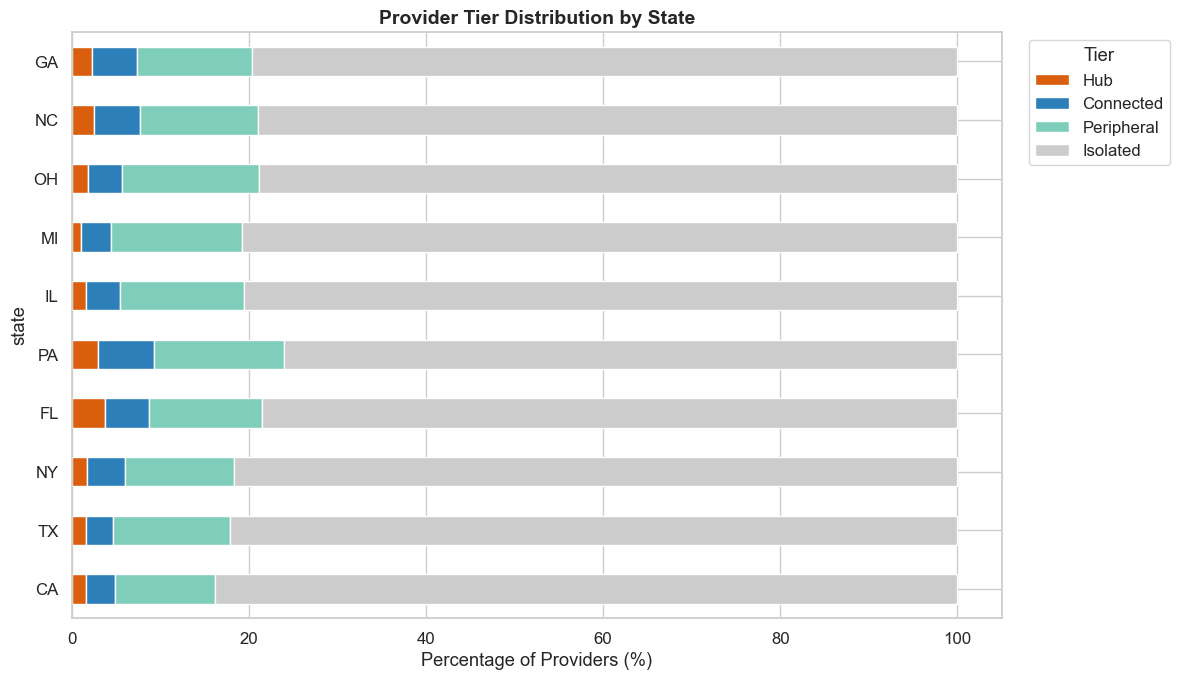

In [20]:
# -------------------------------------------------------------------
# 6c. Tier Distribution by State (Top 10 States)
# -------------------------------------------------------------------

top10_states = provider_net["state"].value_counts().head(10).index.tolist()
state_tier = provider_net[provider_net["state"].isin(top10_states)].copy()

cross = pd.crosstab(state_tier["state"], state_tier["tier"], normalize="index") * 100
cross = cross[tier_order]  # consistent column order
cross = cross.loc[top10_states]  # consistent row order

fig, ax = plt.subplots(figsize=(12, 7))
colors = [PROJECT_COLORS["accent"], PROJECT_COLORS["primary"],
          PROJECT_COLORS["secondary"], "#cccccc"]
cross.plot(kind="barh", stacked=True, ax=ax, color=colors, edgecolor="white")
ax.set_xlabel("Percentage of Providers (%)")
ax.set_title("Provider Tier Distribution by State", fontsize=14, fontweight="bold")
ax.legend(title="Tier", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [25]:
# -------------------------------------------------------------------
# EXPORT: State × Tier treemap for Tableau
# -------------------------------------------------------------------
# Hierarchy: State → Provider Tier | Size: Provider Count
# -------------------------------------------------------------------

US_STATES = {
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "DC", "FL",
    "GA", "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME",
    "MD", "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH",
    "NJ", "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI",
    "SC", "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY"
}

us_providers = provider_net[provider_net["state"].isin(US_STATES)]

state_tier = (
    us_providers
    .groupby(["state", "tier"])
    .size()
    .reset_index(name="Provider Count")
)

# Add state totals for percentage calculation
state_totals = us_providers.groupby("state").size().reset_index(name="State Total")
state_tier = state_tier.merge(state_totals, on="state")
state_tier["Percent of State"] = (
    state_tier["Provider Count"] / state_tier["State Total"] * 100
).round(1)

state_tier.columns = ["State", "Provider Tier", "Provider Count", "State Total", "Percent of State"]

state_tier.to_csv(OUTPUT_DIR / "tableau_state_tier_treemap.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'tableau_state_tier_treemap.csv'}")
print(f"  {len(state_tier)} rows (state × tier combinations)")
display(state_tier.head(12))

Saved: ../data/outputs/tableau_state_tier_treemap.csv
  203 rows (state × tier combinations)


,State,Provider Tier,Provider Count,State Total,Percent of State
0,AK,Connected,5,141,3.5
1,AK,Hub,4,141,2.8
2,AK,Isolated,127,141,90.1
3,AK,Peripheral,5,141,3.5
4,AL,Connected,88,706,12.5
5,AL,Hub,45,706,6.4
6,AL,Isolated,413,706,58.5
7,AL,Peripheral,160,706,22.7
8,AR,Connected,36,365,9.9
9,AR,Hub,17,365,4.7


In [21]:
# -------------------------------------------------------------------
# 6d. Top 20 Hub Providers
# -------------------------------------------------------------------

hubs = provider_net[provider_net["tier"] == "Hub"].nlargest(20, "betweenness")

print("Top 20 Hub Providers (by betweenness centrality):")
display(hubs[[
    "npi", "first_name", "last_name", "subspecialty", "city", "state",
    "total_degree", "weighted_degree", "betweenness", "eigenvector"
]].reset_index(drop=True))

Top 20 Hub Providers (by betweenness centrality):


,npi,first_name,last_name,subspecialty,city,state,total_degree,weighted_degree,betweenness,eigenvector
0,1790746600,JACOB,ROTMENSCH,Gynecologic Oncology,CHICAGO,IL,55,1110,0.038919,7.871712e-18
1,1235136920,RALPH,KRAMER,Obstetrics & Gynecology,STUART,VA,76,2053,0.030297,1.715083e-14
2,1932262672,JUDITH,HIDALGO-AHMED,Obstetrics & Gynecology,ELKTON,MD,21,379,0.029522,7.285732e-14
3,1326030966,FRANK,CIRISANO,Gynecologic Oncology,DELRAY BEACH,FL,34,600,0.024880,1.425156e-13
4,1679765887,SWATHI,VANGURI,Obstetrics & Gynecology,WILMINGTON,DE,55,992,0.022634,-1.353409e-17
5,1821087669,DENISE,POULOS,Gynecology,OAK LAWN,IL,14,306,0.022556,2.762016e-18
6,1114298452,ROBERT,KLEIN,Obstetrics & Gynecology,BOCA RATON,FL,202,3735,0.020598,3.391023e-17
7,1629068044,THOMAS,RUTHERFORD,Gynecologic Oncology,TAMPA,FL,26,341,0.018965,6.435147e-19
8,1588625644,CHARLENE,OKOMSKI,Obstetrics & Gynecology,CELEBRATION,FL,14,260,0.018717,5.293884e-14
9,1811952393,JOEL,BACKER,Obstetrics & Gynecology,MIRAMAR,FL,39,716,0.017557,-3.163345e-18


In [26]:
# -------------------------------------------------------------------
# EXPORT: Top hub providers for Tableau city map and table
# -------------------------------------------------------------------
# Tableau geocodes by City + State automatically.
# ZIP5 included as backup geocoding field.
# -------------------------------------------------------------------

hubs = provider_net[provider_net["tier"] == "Hub"].copy()

for col in ["total_degree", "weighted_degree", "betweenness", "eigenvector", "obgyn_degree"]:
    hubs[col] = pd.to_numeric(hubs[col], errors="coerce")

top_hubs = hubs.nlargest(50, "betweenness")

hub_export = top_hubs[[
    "first_name", "last_name", "subspecialty", "city", "state", "zip5",
    "total_degree", "weighted_degree", "betweenness", "obgyn_degree"
]].copy()

hub_export["Betweenness"] = hub_export["betweenness"].round(6)
hub_export["Provider Name"] = hub_export["first_name"] + " " + hub_export["last_name"]
hub_export["Total Connections"] = hub_export["total_degree"].astype(int)
hub_export["Shared Patients"] = hub_export["weighted_degree"].astype(int)
hub_export["OB-GYN Connections"] = hub_export["obgyn_degree"].astype(int)

hub_export = hub_export.rename(columns={
    "subspecialty": "Subspecialty",
    "city": "City",
    "state": "State",
    "zip5": "ZIP Code"
})

hub_export = hub_export[[
    "Provider Name", "Subspecialty", "City", "State", "ZIP Code",
    "Total Connections", "OB-GYN Connections", "Shared Patients", "Betweenness"
]].reset_index(drop=True)

hub_export.to_csv(OUTPUT_DIR / "tableau_hub_providers.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'tableau_hub_providers.csv'}")
print(f"  {len(hub_export)} hub providers")
display(hub_export)

Saved: ../data/outputs/tableau_hub_providers.csv
  50 hub providers


,Provider Name,Subspecialty,City,State,ZIP Code,Total Connections,OB-GYN Connections,Shared Patients,Betweenness
0,JACOB ROTMENSCH,Gynecologic Oncology,CHICAGO,IL,60637,55,1,1110,0.038919
1,RALPH KRAMER,Obstetrics & Gynecology,STUART,VA,24171,76,0,2053,0.030297
2,JUDITH HIDALGO-AHMED,Obstetrics & Gynecology,ELKTON,MD,21921,21,0,379,0.029522
3,FRANK CIRISANO,Gynecologic Oncology,DELRAY BEACH,FL,33484,34,0,600,0.024880
4,SWATHI VANGURI,Obstetrics & Gynecology,WILMINGTON,DE,19810,55,0,992,0.022634
5,DENISE POULOS,Gynecology,OAK LAWN,IL,60453,14,1,306,0.022556
6,ROBERT KLEIN,Obstetrics & Gynecology,BOCA RATON,FL,33496,202,0,3735,0.020598
7,THOMAS RUTHERFORD,Gynecologic Oncology,TAMPA,FL,33606,26,4,341,0.018965
8,CHARLENE OKOMSKI,Obstetrics & Gynecology,CELEBRATION,FL,34747,14,0,260,0.018717
9,JOEL BACKER,Obstetrics & Gynecology,MIRAMAR,FL,33027,39,0,716,0.017557


---

## 7. State-Level Network Metrics

Aggregate network metrics to the state level for geographic comparison in Phase 5.

In [22]:
# -------------------------------------------------------------------
# 7a. State-Level Aggregation
# -------------------------------------------------------------------

state_metrics = provider_net.groupby("state").agg(
    n_providers=("npi", "count"),
    n_connected=("is_connected", "sum"),
    n_hubs=("tier", lambda x: (x == "Hub").sum()),
    n_isolated=("tier", lambda x: (x == "Isolated").sum()),
    mean_degree=("total_degree", "mean"),
    median_degree=("total_degree", "median"),
    mean_betweenness=("betweenness", "mean"),
    mean_eigenvector=("eigenvector", "mean"),
    mean_weighted_degree=("weighted_degree", "mean"),
    n_communities=("community", lambda x: x[x >= 0].nunique())
).reset_index()

state_metrics["pct_connected"] = (state_metrics["n_connected"] / state_metrics["n_providers"] * 100).round(1)
state_metrics["pct_hub"] = (state_metrics["n_hubs"] / state_metrics["n_providers"] * 100).round(1)
state_metrics["pct_isolated"] = (state_metrics["n_isolated"] / state_metrics["n_providers"] * 100).round(1)

state_metrics = state_metrics.sort_values("n_providers", ascending=False)

print(f"State-level network metrics: {len(state_metrics)} states")
display(state_metrics.head(15))

State-level network metrics: 97 states


,state,n_providers,n_connected,n_hubs,n_isolated,mean_degree,median_degree,mean_betweenness,mean_eigenvector,mean_weighted_degree,n_communities,pct_connected,pct_hub,pct_isolated
16,CA,6655,1075,109,5580,0.938542,0.0,4.035404e-05,1.759548e-16,16.832757,99,16.2,1.6,83.8
85,TX,4611,823,71,3788,0.946432,0.0,3.296913e-05,9.681910e-11,17.324442,73,17.8,1.5,82.2
61,NY,4474,818,78,3656,1.062137,0.0,2.901620e-05,2.389945e-16,18.335270,104,18.3,1.7,81.7
26,FL,3628,781,134,2847,2.005237,0.0,1.079738e-04,2.063812e-04,36.731257,97,21.5,3.7,78.5
68,PA,2642,633,77,2009,1.564345,0.0,5.991147e-05,1.912079e-19,25.432248,85,24.0,2.9,76.0
36,IL,2586,502,41,2084,0.966744,0.0,6.561406e-05,1.469137e-10,16.042537,48,19.4,1.6,80.6
46,MI,2125,408,21,1717,0.760000,0.0,5.992278e-05,5.117981e-08,12.471059,49,19.2,1.0,80.8
62,OH,2081,440,38,1641,1.058145,0.0,5.331486e-06,1.149234e-09,17.153292,42,21.1,1.8,78.9
52,NC,2010,423,50,1587,1.361194,0.0,2.446895e-05,7.752636e-10,22.973134,61,21.0,2.5,79.0
30,GA,1905,387,43,1518,1.138583,0.0,7.019416e-05,1.339487e-07,18.931234,46,20.3,2.3,79.7


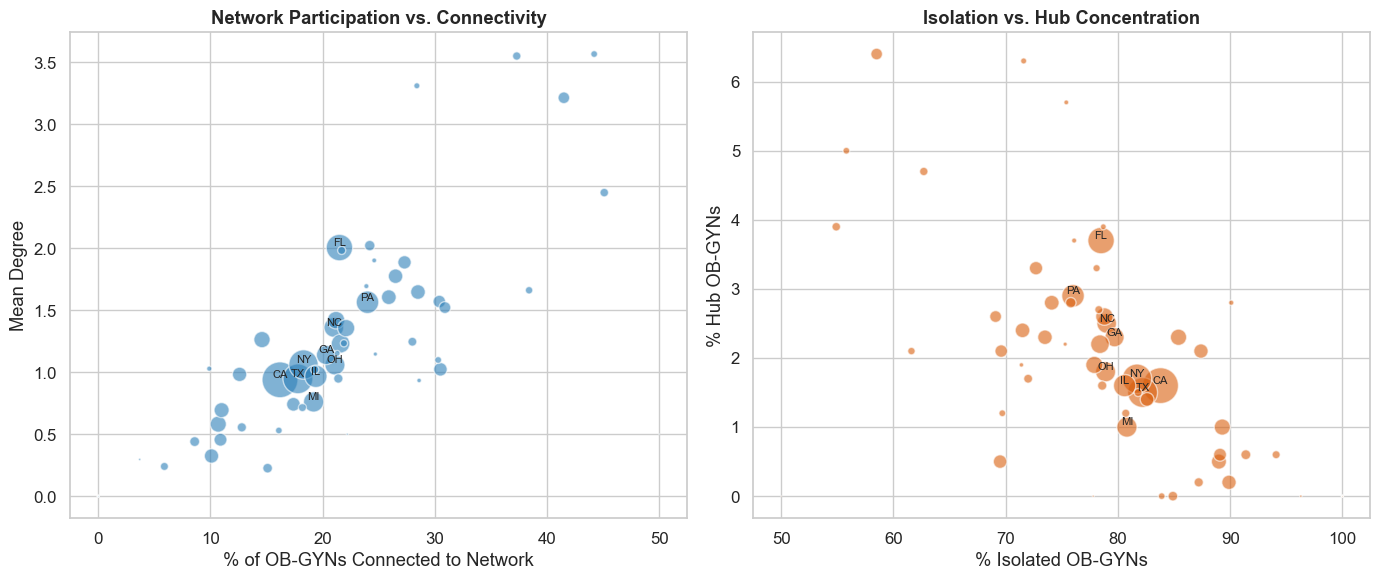

In [23]:
# -------------------------------------------------------------------
# 7b. Scatter: % Connected vs. Mean Degree by State
# -------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: % Connected vs Mean Degree
ax = axes[0]
ax.scatter(state_metrics["pct_connected"], state_metrics["mean_degree"],
           s=state_metrics["n_providers"] / 10, alpha=0.6,
           color=PROJECT_COLORS["primary"], edgecolors="white")
for _, row in state_metrics.head(10).iterrows():
    ax.annotate(row["state"], (row["pct_connected"], row["mean_degree"]),
                fontsize=8, ha="center", va="bottom")
ax.set_xlabel("% of OB-GYNs Connected to Network")
ax.set_ylabel("Mean Degree")
ax.set_title("Network Participation vs. Connectivity", fontweight="bold")

# Right: % Isolated vs % Hub
ax = axes[1]
ax.scatter(state_metrics["pct_isolated"], state_metrics["pct_hub"],
           s=state_metrics["n_providers"] / 10, alpha=0.6,
           color=PROJECT_COLORS["accent"], edgecolors="white")
for _, row in state_metrics.head(10).iterrows():
    ax.annotate(row["state"], (row["pct_isolated"], row["pct_hub"]),
                fontsize=8, ha="center", va="bottom")
ax.set_xlabel("% Isolated OB-GYNs")
ax.set_ylabel("% Hub OB-GYNs")
ax.set_title("Isolation vs. Hub Concentration", fontweight="bold")

plt.tight_layout()
plt.show()

In [29]:
# -------------------------------------------------------------------
# EXPORT: State network participation vs connectivity for Tableau scatter
# -------------------------------------------------------------------
# X: Pct Connected | Y: Mean Degree | Size: Total Providers | Label: State
# Tooltip: hubs, isolated, communities, etc.
# Filtered to 50 states + DC.
# -------------------------------------------------------------------

US_STATES = {
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "DC", "FL",
    "GA", "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME",
    "MD", "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH",
    "NJ", "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI",
    "SC", "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY"
}

state_scatter = state_metrics[state_metrics["state"].isin(US_STATES)].copy()

state_scatter = state_scatter.rename(columns={
    "state": "State",
    "n_providers": "Total OB-GYNs",
    "n_connected": "Connected OB-GYNs",
    "n_hubs": "Hub Providers",
    "n_isolated": "Isolated OB-GYNs",
    "mean_degree": "Mean Degree",
    "median_degree": "Median Degree",
    "mean_betweenness": "Mean Betweenness",
    "mean_weighted_degree": "Mean Shared Patients",
    "n_communities": "Communities Detected",
    "pct_connected": "Pct Connected",
    "pct_hub": "Pct Hub",
    "pct_isolated": "Pct Isolated"
})

state_scatter["Mean Degree"] = state_scatter["Mean Degree"].round(2)
state_scatter["Mean Betweenness"] = state_scatter["Mean Betweenness"].round(6)
state_scatter["Mean Shared Patients"] = state_scatter["Mean Shared Patients"].round(1)

state_scatter = state_scatter[[
    "State", "Total OB-GYNs", "Connected OB-GYNs", "Hub Providers",
    "Isolated OB-GYNs", "Pct Connected", "Pct Hub", "Pct Isolated",
    "Mean Degree", "Median Degree", "Mean Betweenness",
    "Mean Shared Patients", "Communities Detected"
]].reset_index(drop=True)

state_scatter.to_csv(OUTPUT_DIR / "tableau_state_network_scatter.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'tableau_state_network_scatter.csv'}")
print(f"  {len(state_scatter)} states")
display(state_scatter)

Saved: ../data/outputs/tableau_state_network_scatter.csv
  51 states


,State,Total OB-GYNs,Connected OB-GYNs,Hub Providers,Isolated OB-GYNs,Pct Connected,Pct Hub,Pct Isolated,Mean Degree,Median Degree,Mean Betweenness,Mean Shared Patients,Communities Detected
0,CA,6655,1075,109,5580,16.2,1.6,83.8,0.94,0.0,0.000040,16.8,99
1,TX,4611,823,71,3788,17.8,1.5,82.2,0.95,0.0,0.000033,17.3,73
2,NY,4474,818,78,3656,18.3,1.7,81.7,1.06,0.0,0.000029,18.3,104
3,FL,3628,781,134,2847,21.5,3.7,78.5,2.01,0.0,0.000108,36.7,97
4,PA,2642,633,77,2009,24.0,2.9,76.0,1.56,0.0,0.000060,25.4,85
5,IL,2586,502,41,2084,19.4,1.6,80.6,0.97,0.0,0.000066,16.0,48
6,MI,2125,408,21,1717,19.2,1.0,80.8,0.76,0.0,0.000060,12.5,49
7,OH,2081,440,38,1641,21.1,1.8,78.9,1.06,0.0,0.000005,17.2,42
8,NC,2010,423,50,1587,21.0,2.5,79.0,1.36,0.0,0.000024,23.0,61
9,GA,1905,387,43,1518,20.3,2.3,79.7,1.14,0.0,0.000070,18.9,46


---

## 8. Export

In [27]:
# -------------------------------------------------------------------
# EXPORT: Enriched provider table
# -------------------------------------------------------------------

PROVIDERS_NET_OUT = OUTPUT_DIR / "obgyn_providers_network.csv"
COMMUNITY_OUT = OUTPUT_DIR / "community_summary.csv"
STATE_METRICS_OUT = OUTPUT_DIR / "state_network_metrics.csv"

# 1. Provider table with network metrics
provider_net.to_csv(PROVIDERS_NET_OUT, index=False)
print(f"Saved: {PROVIDERS_NET_OUT}")
print(f"  {len(provider_net):,} rows x {len(provider_net.columns)} cols")
print(f"  Size: {PROVIDERS_NET_OUT.stat().st_size / (1024**2):.1f} MB\n")

# 2. Community summary
comm_profile_df.to_csv(COMMUNITY_OUT, index=False)
print(f"Saved: {COMMUNITY_OUT}")
print(f"  {len(comm_profile_df)} communities profiled\n")

# 3. State-level network metrics
state_metrics.to_csv(STATE_METRICS_OUT, index=False)
print(f"Saved: {STATE_METRICS_OUT}")
print(f"  {len(state_metrics)} states")

Saved: ../data/outputs/obgyn_providers_network.csv
  60,422 rows x 18 cols
  Size: 7.7 MB

Saved: ../data/outputs/community_summary.csv
  15 communities profiled

Saved: ../data/outputs/state_network_metrics.csv
  97 states


---

## Phase 4 Summary

In [28]:
# -------------------------------------------------------------------
# SUMMARY
# -------------------------------------------------------------------

print("=" * 75)
print("PHASE 4 — NETWORK ANALYSIS SUMMARY")
print("=" * 75)

print(f"\n--- Graph Topology ---")
print(f"  Full graph:      {G_full.number_of_nodes():,} nodes, {G_full.number_of_edges():,} edges")
print(f"  OB-GYN subgraph: {G_obgyn.number_of_nodes():,} nodes, {G_obgyn.number_of_edges():,} edges")
print(f"  Giant component: {component_sizes_full[0]:,} nodes ({component_sizes_full[0]/G_full.number_of_nodes()*100:.1f}%)")
print(f"  Avg clustering:  {avg_clustering_full:.4f} (full), {avg_clustering_obgyn:.4f} (OB-GYN)")

print(f"\n--- Centrality (OB-GYN providers) ---")
print(f"  Median degree centrality:  {np.median(dc_values):.6f}")
print(f"  Median betweenness:        {np.median(bc_values):.6f}")
print(f"  Median eigenvector:        {np.median(ec_values):.6f}")

print(f"\n--- Communities (OB-GYN subgraph) ---")
print(f"  Communities detected: {n_communities}")
print(f"  Modularity: {modularity:.4f}")

print(f"\n--- Provider Tiers ---")
for tier in tier_order:
    n = (provider_net["tier"] == tier).sum()
    pct = n / len(provider_net) * 100
    print(f"  {tier:<12} {n:>6,} ({pct:.1f}%)")

print(f"\n--- Outputs ---")
print(f"  obgyn_providers_network.csv  — provider table + centrality + community + tier")
print(f"  community_summary.csv        — top community geographic profiles")
print(f"  state_network_metrics.csv    — state-level network aggregations")

print(f"\n{'='*75}")
print(f"Ready to proceed to Phase 5: Geographic Overlay (05_geographic_overlay.ipynb)")

PHASE 4 — NETWORK ANALYSIS SUMMARY

--- Graph Topology ---
  Full graph:      49,341 nodes, 70,980 edges
  OB-GYN subgraph: 2,791 nodes, 2,429 edges
  Giant component: 25,327 nodes (51.3%)
  Avg clustering:  0.0020 (full), 0.0268 (OB-GYN)

--- Centrality (OB-GYN providers) ---
  Median degree centrality:  0.000041
  Median betweenness:        0.000000
  Median eigenvector:        0.000000

--- Communities (OB-GYN subgraph) ---
  Communities detected: 957
  Modularity: 0.9954

--- Provider Tiers ---
  Hub           1,225 (2.0%)
  Connected     2,701 (4.5%)
  Peripheral    8,301 (13.7%)
  Isolated     48,195 (79.8%)

--- Outputs ---
  obgyn_providers_network.csv  — provider table + centrality + community + tier
  community_summary.csv        — top community geographic profiles
  state_network_metrics.csv    — state-level network aggregations

Ready to proceed to Phase 5: Geographic Overlay (05_geographic_overlay.ipynb)


---

## Next Steps

Proceed to **`05_geographic_overlay.ipynb`**:
1. Map provider ZIP codes to county FIPS codes
2. Compute county-level network metrics (provider density, mean degree, hub concentration)
3. Join with maternal morbidity rates
4. Choropleth maps — provider density, network connectivity, morbidity rates
5. Regression analysis — do network features predict maternal outcomes?
6. Identify target counties — high morbidity + weak networks = opportunity for virtual care